## Лабораторна робота №1 з теми "Класифікація"
## з дисципліни "Актуальні проблеми data mining"
виконала студентка групи ММШІ-1

Тузова Лариса

## Постановка задачі
Реалізувати програмно алгоритми класифікації 1-Rule, Naive Bayes, Decision Tree, kNN. Дослідити результат навчання кожного класифікатора, зробити висновок про доцільність використання того чи іншого класифікатора та вплив гіперпараметрів, провести порівняльний аналіз отриманих класифікаторів.



## Опис використаного датасету

Для виконання даної роботи було обрано датасет <a source = "https://archive.ics.uci.edu/dataset/236/seeds">«Seeds»</a>, який є присвяченим вимірюванню та зовнішньому дослідженню насінин пшениці. Обраний датасет містить 210 записів, для кожного з яких записано значення семи числових ознак.

Об’єкти цього датасету можуть належати до трьох класів, а саме – трьох сортів пшениці, Kama, Rosa та Canadian, кожен з яких представлений у датасеті в обсязі 70 спостережень.

Ознаки, що описані датасетом: grain area, perimeter, compactness, length, width, asymmetry factor, length of the kernel groove.


![alt text](dataset_header.png)

## Попередня обробка даних
Імпортуємо необхідні для попередньої обробки даних датасету бібліотеки, а також модулі, що містять реалізовані класифікатори.

In [6]:
from enum import unique
import numpy
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import distinct
from sympy import flatten
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from bayes import naiveBayes
import knn
import onerule
import decisionTree

Завантажимо датасет з файлу та перевіримо, чи є коректною кількість записів та структура результуючого дата фрейму.

In [7]:
# Loading the dataset
numDataset = numpy.loadtxt("seeds_dataset.txt")
labels = pd.DataFrame(data = numDataset[:, 7])
dataset = pd.DataFrame(data = numDataset[:, 0:7], columns=["area", "perimeter", "compactness", 
                                                           "length", "width", "asymmetry", "groove"])
print("The size of the dataset: " + str(len(dataset)) + " records\n")
print(dataset.head(10))

The size of the dataset: 210 records

    area  perimeter  compactness  length  width  asymmetry  groove
0  15.26      14.84       0.8710   5.763  3.312      2.221   5.220
1  14.88      14.57       0.8811   5.554  3.333      1.018   4.956
2  14.29      14.09       0.9050   5.291  3.337      2.699   4.825
3  13.84      13.94       0.8955   5.324  3.379      2.259   4.805
4  16.14      14.99       0.9034   5.658  3.562      1.355   5.175
5  14.38      14.21       0.8951   5.386  3.312      2.462   4.956
6  14.69      14.49       0.8799   5.563  3.259      3.586   5.219
7  14.11      14.10       0.8911   5.420  3.302      2.700   5.000
8  16.63      15.46       0.8747   6.053  3.465      2.040   5.877
9  16.44      15.25       0.8880   5.884  3.505      1.969   5.533


Перевіримо датасет на наявність аномальних записів (викидів) та нульових значень, видаляючи їх у випадку знаходження. Для визначення запису як аномального для кожної розглянутої ознаки датасету використаємо стандартну оцінку (z-score), яка визначає, на яку кількість стандартних відхилень кожне значення відрізняється від середнього за вибіркою. В якості порогового значення z-score оберемо z = 3.

In [8]:
# Screening for outliers and zero values
outliers = []

for i in range(7):
    column = numDataset[:, i]
    z = numpy.abs(stats.zscore(column))
    colOutliers = numpy.where(z > 3)[0]  # get indices only
    outliers.extend(colOutliers)

outliers = set(outliers)

# Converting to index labels
outlier_labels = dataset.index[list(outliers)]
anomalies = dataset.loc[outlier_labels]

print("Anomalous records:")
print(anomalies)

dataset = dataset.drop(outlier_labels)
labels = labels.drop(outlier_labels)

print("The size of the dataset after removing outliers: " + str(len(dataset)) + " records\n")

# Removing rows with zeroes
mask = (dataset.iloc[:, :7] == 0).any(axis=1)
dataset = dataset[~mask]
labels = labels[~mask]

print("The size of the dataset after removing zeroes: " + str(len(dataset)) + " records\n")


Anomalous records:
     area  perimeter  compactness  length  width  asymmetry  groove
203  12.7      13.41       0.8874   5.183  3.091      8.456   5.000
207  13.2      13.66       0.8883   5.236  3.232      8.315   5.056
The size of the dataset after removing outliers: 208 records

The size of the dataset after removing zeroes: 208 records



Як показує гістограма, представлена нижче, після виключення аномальних спостережень датасет продовжує бути збалансованим за класами:

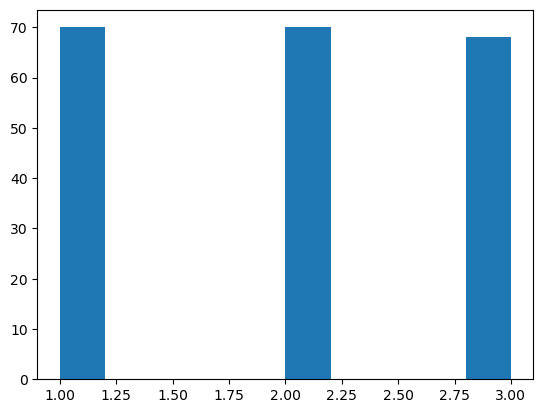

In [9]:
plt.hist(labels)
plt.show()

Для зрівняння впливу різних ознак на результат класифікації, проведемо нормалізацію даних з використанням техніки мінімаксу.

In [10]:
# Normalization (min-max)
scaledDataset = dataset.copy()
for column in dataset.columns:
    scaledDataset[column] = (scaledDataset[column] - scaledDataset[column].min()) / (scaledDataset[column].max() - scaledDataset[column].min())

print(scaledDataset.head(10))

       area  perimeter  compactness    length     width  asymmetry    groove
0  0.440982   0.502066     0.570780  0.486486  0.486101   0.215405  0.345150
1  0.405099   0.446281     0.662432  0.368806  0.501069   0.037417  0.215165
2  0.349386   0.347107     0.879310  0.220721  0.503920   0.286126  0.150665
3  0.306893   0.316116     0.793103  0.239302  0.533856   0.221027  0.140817
4  0.524079   0.533058     0.864791  0.427365  0.664291   0.087278  0.322994
5  0.357885   0.371901     0.789474  0.274212  0.486101   0.251062  0.215165
6  0.387158   0.429752     0.651543  0.373874  0.448325   0.417361  0.344658
7  0.332389   0.349174     0.753176  0.293356  0.478974   0.286274  0.236829
8  0.570349   0.630165     0.604356  0.649775  0.595153   0.188625  0.668636
9  0.552408   0.586777     0.725045  0.554617  0.623664   0.178121  0.499261


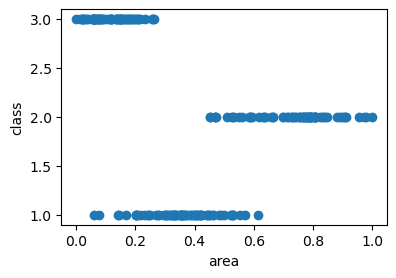

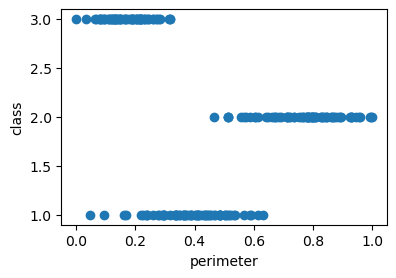

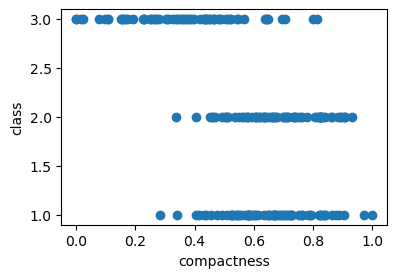

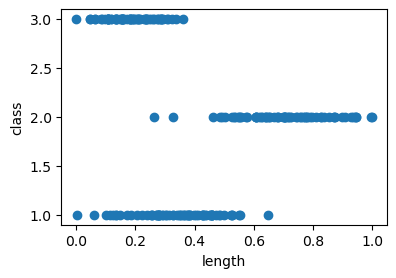

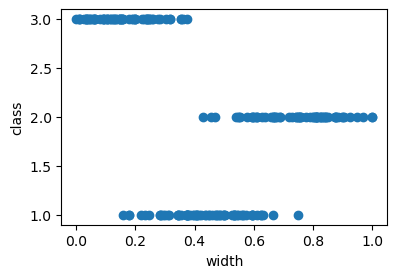

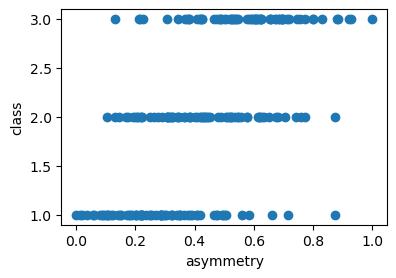

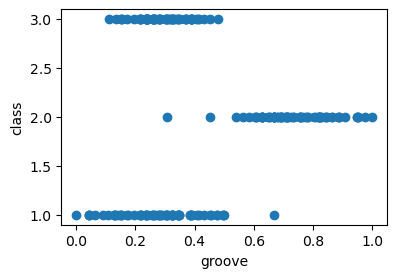

In [11]:
for i in range(7):
    fig1, fig = plt.subplots(figsize=(4.2, 2.8))
    fig.scatter(scaledDataset[scaledDataset.columns.values[i]].tolist(), labels)
    fig.set_xlabel(scaledDataset.columns.values[i])
    fig.set_ylabel("class")
    plt.show()

Завершимо передобробку даних датасету, сформувавши тренувальну та тестувальну множини даних із поділом 80%/20% відповідно.

Також, оскільки дані датасету було отримано в результаті вимірювання геометричних характеристик об'єктів, що вивчалися (насінин), введемо біни (відрізки, на які ділитиметься діапазон значень змінних) для підвищення зручності використання неперервних геометричних змінних у таких алгоритмах, як 1-Rule та Naive Bayes.

In [12]:
scaledDataset = numpy.array(scaledDataset)
labels = numpy.array(labels).astype(numpy.int16)

bins = 100
trainX, testX, trainY, testY = train_test_split(
    scaledDataset, labels, test_size=0.2, random_state=42)

## Алгоритм 1-rule

Даний алгоритм здійснює класифікацію даних на основі обраного в процесі тренування найкращого правила - тобто такого, яке пов'язує значення однієї з ознак зі значенням класу із найменшою кількістю помилок.

In [17]:
import numpy as np

def oneRule(trainDataset, labels, testDataset, testLabels, bins):
    num_features = trainDataset.shape[1]
    class_labels = np.unique(labels).astype(int)
    num_classes = len(class_labels)

    featureClasses = np.zeros((num_features, bins + 1, num_classes))
    rules = np.zeros((num_features, bins + 1))

    label_to_index = {label: idx for idx, label in enumerate(class_labels)}

    for i in range(len(trainDataset)):
        for j in range(num_features):
            valueIndex = min(int(trainDataset[i][j] * bins), bins)
            class_idx = label_to_index[int(labels[i][0])]
            featureClasses[j][valueIndex][class_idx] += 1

    for i in range(num_features):
        for j in range(bins + 1):
            rules[i][j] = class_labels[np.argmax(featureClasses[i][j])]

    errors = np.zeros(num_features)

    for i in range(len(trainDataset)):
        for j in range(num_features):
            valueIndex = min(int(trainDataset[i][j] * bins), bins)
            if labels[i][0] != rules[j][valueIndex]:
                errors[j] += 1

    bestFeature = np.argmin(errors)
    print("The best feature is {}".format(bestFeature))

    bestRule = rules[bestFeature]
    print("Best rule is {}".format(bestRule))

    correct = 0

    for i in range(len(trainDataset)):
        value = trainDataset[i][bestFeature]
        valueIndex = min(int(value * bins), bins)
        predicted = bestRule[valueIndex]

        if labels[i][0] == predicted:
            correct += 1

    accuracyTrain = correct / len(trainDataset)

    correct_test = 0
    confusion_test = np.zeros((num_classes, num_classes))

    for i in range(len(testDataset)):
        value = testDataset[i][bestFeature]
        true = int(testLabels[i][0])

        valueIndex = min(int(value * bins), bins)
        predicted = int(bestRule[valueIndex])

        true_idx = label_to_index[true]
        pred_idx = label_to_index[predicted]

        confusion_test[true_idx][pred_idx] += 1

        if true == predicted:
            correct_test += 1

    accuracyTest = correct_test / len(testDataset)

    return accuracyTrain, accuracyTest, confusion_test

    def oneRule_predict(x, bestFeature, bestRule, bins):
        valueIndex = min(int(x[bestFeature] * bins), bins)
        return int(bestRule[valueIndex])

Вважатимемо кількість бінів гіперпараметром цього алгоритму, оскільки від неї залежить кількість дискретних "категорій", на які ділиться діапазон значень ознаки та, відповідно, точність, з якою ці значення відрізніються одне від одного. Розглянемо показники точності алгоритму за різних значень кількості бінів:

|Кількість бінів| 25 | 40 | 50 | 75 | 100 |
|:-------------:|:--:|:--:|:---:|:---:|:---:|
| Точність |80.9%|85.71%|80.95%|76.19%|71.43%|

Як можна побачити, найвище значення точності на тестувальному наборі даних досягається для 40 бінів (і, як показало тестування, при цьому найкращою ознакою обирається ознака 1, area). Порівняння формату правила та побудови графіку розсіювання значень даної ознаки показує, що саме за такої кількості бінів правило якнайкраще повторює цю будову:

![alt text](1rule.png)

Best rule is [3. 1. 3. 3. 3. 3. 3. 3. 3. 3. 3. 1. 3. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 1.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 2. 2. 2. 2.]

Таким чином, можна зробити висновок, що побудований таким чином класифікатор, хоч і є простим та швидким, компенсує ці переваги не найвищою точністю і є в значній мірі залежним від розподілу значень ознак, що вивчається. Його використання може бути рекомендованим тільки в ситуаціях із добре роздільними класами та дуже високою пріоритетністю економії часу та ресурсів.

## Алгоритм Naive Bayes

Даний алгоритм використовує для класифікації даних формулу формулу апостеріорної імовірності Байєса, яка визначає імовірність кожного з класів при даному наборі значень ознак за умови частоти появи даних значень у цьому класі.

![alt text](selection_005.png)

In [18]:
import numpy as np

def naiveBayes(trainDataset, testDataset, labels, testLabels, bins):
    classesP, featuresP, class_labels, label_to_index = trainBayes(trainDataset, labels, bins)

    accuracyTrain, _ = testBayes(trainDataset, labels, bins, classesP, featuresP, class_labels, label_to_index)
    accuracyTest, cmTest = testBayes(testDataset, testLabels, bins, classesP, featuresP, class_labels, label_to_index)

    return accuracyTrain, accuracyTest, cmTest


def trainBayes(dataset, labels, bins):
    num_features = dataset.shape[1]
    class_labels = np.unique(labels).astype(int)
    num_classes = len(class_labels)

    label_to_index = {label: idx for idx, label in enumerate(class_labels)}

    classesP = np.zeros(num_classes)
    classCounts = np.zeros(num_classes)

    for l in labels:
        idx = label_to_index[int(l[0])]
        classesP[idx] += 1
        classCounts[idx] += 1

    classesP = classesP / len(labels)

    featuresP = np.zeros((num_classes, num_features, bins + 1))

    for i in range(len(dataset)):
        class_idx = label_to_index[int(labels[i][0])]
        for j in range(num_features):
            valueIndex = min(int(dataset[i][j] * bins), bins)
            featuresP[class_idx][j][valueIndex] += 1

    featuresP += 1

    for i in range(num_classes):
        featuresP[i] /= (classCounts[i] + bins + 1)

    return classesP, featuresP, class_labels, label_to_index


def testBayes(dataset, labels, bins, classesP, featuresP, class_labels, label_to_index):
    correct = 0
    num_classes = len(class_labels)
    confusion = np.zeros((num_classes, num_classes))

    for i in range(len(dataset)):
        probabilities = []

        for j in range(num_classes):
            classProbability = np.log(classesP[j])

            for f in range(dataset.shape[1]):
                valueIndex = min(int(dataset[i][f] * bins), bins)
                classProbability += np.log(featuresP[j][f][valueIndex] + 1e-9)

            probabilities.append(classProbability)

        pred_idx = np.argmax(probabilities)
        finalClass = class_labels[pred_idx]

        trueClass = int(labels[i][0])
        true_idx = label_to_index[trueClass]

        confusion[true_idx][pred_idx] += 1

        if finalClass == trueClass:
            correct += 1

    return correct / len(dataset), confusion

    def naiveBayes_predict(x, classesP, featuresP, bins):
        probabilities = []

        for j in range(len(classesP)):
            classProbability = np.log(classesP[j])

            for f in range(7):
                valueIndex = min(int(x[f] * bins), bins)
                classProbability += np.log(featuresP[j][f][valueIndex] + 1e-9)

            probabilities.append(classProbability)

        return int(np.argmax(probabilities) + 1)

Для даного алгоритму кількість бінів також є важливим гіперпараметром, оскільки вона визначає кількість унікальних значень ознаки, для яких буде визначатися сумарна імовірність появи у класі. Однак цей алгоритм, на відміну від попередника, показує найкращу точність для значення у 100 бінів, як демонструє таблиця:

|Кількість бінів| 50 | 75 | 100 | 150 | 300 |
|:-------------:|:--:|:--:|:---:|:---:|:---:|
| Точність |80.95%|83.33%|85.71%|83.33%|80.95%|

Також варто зазначити, що даний алгоритм виявив максимальну точність, ідентичну точності 1-Rule, однак він зберігає вищі значення точності в цілому в ширшому діапазоні, що дає підстави припускати, що Naive Nayes є стійкішим до розподілу значень ознак. Він є технічно складнішим за свого попередника і вимагає більшої кількості пам'яті для збереження масивів імовірностей значень ознак розмірністю (кількість класів, кількість ознак, кількість бінів), але також є швидким і може бути використаним у ситуаціях, що вимагають роботи з різноманітними даними і менш роздільними класами.

## Алгоритм Decision Tree

Даний алгоритм під час тренування будує "дерево рішень", якому слідуватиме в процесі класифікації. Кожна нода такого дерева представляє собою предикат над значенням однієї з ознак, а ребра, що з'єднують її з синівськими нодами - можливі значення цього предикату. У кожному з листів дерева розміщується одне значення класу, а на кожному етапі формування нового піддерева вибір предикату здійснюється так, аби отримати максимальну інформаційну вигоду.

In [19]:
from sklearn.metrics import accuracy_score
import numpy as np

class TreeNode:
    def __init__(self, feature_idx=None, threshold=None, prediction_probs=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.prediction_probs = prediction_probs
        self.left = None
        self.right = None

class DecisionTree:
    def __init__(self, max_depth=10, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.tree = None
        self.labels_in_train = None
        self.label_to_index = None

    def trainTree(self, X, Y):
        self.labels_in_train = np.unique(Y).astype(int)
        self.label_to_index = {label: idx for idx, label in enumerate(self.labels_in_train)}
        data = np.concatenate((X, Y.reshape(-1,1)), axis=1)
        self.tree = self._build_tree(data, depth=0)

    def _build_tree(self, data, depth):
        X, y = data[:, :-1], data[:, -1]
        probs = np.array([np.mean(y == lbl) for lbl in self.labels_in_train])

        if depth >= self.max_depth or len(data) <= self.min_samples_leaf or len(np.unique(y)) == 1:
            return TreeNode(prediction_probs=probs)

        best_feat, best_thresh, best_left, best_right = self._find_best_split(data)
        if best_feat is None:
            return TreeNode(prediction_probs=probs)

        node = TreeNode(feature_idx=best_feat, threshold=best_thresh, prediction_probs=probs)
        node.left = self._build_tree(best_left, depth+1)
        node.right = self._build_tree(best_right, depth+1)
        return node

    def _find_best_split(self, data):
        X, y = data[:, :-1], data[:, -1]
        num_features = X.shape[1]
        best_feat, best_thresh = None, None
        best_left, best_right = None, None
        max_gain = -1

        for i in range(num_features):
            thresholds = np.unique(X[:, i])
            for t in thresholds:
                left_mask = X[:, i] <= t
                right_mask = X[:, i] > t
                left_y, right_y = y[left_mask], y[right_mask]

                if len(left_y) < self.min_samples_leaf or len(right_y) < self.min_samples_leaf:
                    continue

                gain = self._entropy(y) - (len(left_y)/len(y)*self._entropy(left_y) + len(right_y)/len(y)*self._entropy(right_y))
                if gain > max_gain:
                    max_gain = gain
                    best_feat = i
                    best_thresh = t
                    best_left = data[left_mask]
                    best_right = data[right_mask]

        return best_feat, best_thresh, best_left, best_right

    def _entropy(self, y):
        probs = np.array([np.mean(y == lbl) for lbl in self.labels_in_train])
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

    def _predict_one(self, x, node):
        while node.left is not None and node.right is not None:
            if x[node.feature_idx] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return self.labels_in_train[np.argmax(node.prediction_probs)]

    def evaluate(self, X_train, Y_train, X_test=None, Y_test=None):
        train_preds = self.predict(X_train)
        train_acc = accuracy_score(Y_train, train_preds)

        print("Train Accuracy:", train_acc)

        num_classes = len(self.labels_in_train)

        if X_test is not None and Y_test is not None:
            test_preds = self.predict(X_test)
            test_acc = accuracy_score(Y_test, test_preds)

            confusion = np.zeros((num_classes, num_classes))

            for i in range(len(Y_test)):
                true = int(Y_test[i].item())
                pred = int(test_preds[i].item())

                true_idx = self.label_to_index[true]
                pred_idx = self.label_to_index[pred]

                confusion[true_idx][pred_idx] += 1

            print("Test Accuracy:", test_acc)
            return confusion

        return np.zeros((num_classes, num_classes))

    def decisionTree_predict(tree, x):
        node = tree
        while node.left is not None and node.right is not None:
            if x[node.feature_idx] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return int(np.argmax(node.prediction_probs) + 1)

## Алгоритм k найближчих сусідів (kNN)

Цей алгоритм виконує класифікацію, порівнюючи відстань від точки, що класифікується, до вже відомих точок, та обираючи k найближчих до неї, після чого клас нової точки визначається на підставі обраних відомих. Вибір може відбуватися на підставі зваженого або незваженого голосування обраних найближчих сусідів.

In [20]:
from collections import Counter
import numpy as np

def kNearestNeighbours(datasetTrain, datasetTest, labelsTrain, labelsTest):
    
    class_labels = np.unique(labelsTrain).astype(int)
    num_classes = len(class_labels)
    label_to_index = {label: idx for idx, label in enumerate(class_labels)}

    best_accuracy = -1
    best_k = None
    best_confusion = None

    for k in range(1, 11):
        accuracy = 0
        confusion = np.zeros((num_classes, num_classes))

        for point in range(len(datasetTest)):
            distances = []
            indexes = []

            for i in range(len(datasetTrain)):
                distances.append(euclids(datasetTest[point], datasetTrain[i]))
                indexes.append(i)

            distances, indexes = zip(*sorted(zip(distances, indexes)))
            neighbours = indexes[:k]

            classes = []
            for n in neighbours:
                classes.append(int(labelsTrain[n][0]))

            finalClass = Counter(classes).most_common(1)[0][0]
            trueClass = int(labelsTest[point][0])

            true_idx = label_to_index[trueClass]
            pred_idx = label_to_index[finalClass]

            confusion[true_idx][pred_idx] += 1

            if finalClass == trueClass:
                accuracy += 1

        accuracy /= len(datasetTest)

        print("Accuracy of {} neighbours: {}".format(k, accuracy))

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
            best_confusion = confusion

    return best_k, best_confusion


def euclids(x, y):
    if x.shape == y.shape:
        distance = 0
        for dim in range(x.shape[0]):
            if dim == 0 or dim == 1:
                distance += 4 * (x[dim] - y[dim]) ** 2
            elif dim == 5 or dim == 6:
                distance += 2 * (x[dim] - y[dim]) ** 2
            else:
                distance += (x[dim] - y[dim]) ** 2

        return np.sqrt(distance)
    else:
        return 0

def kNN_predict(x, trainX, trainY, k):
    distances = []
    indexes = []

    for i in range(len(trainX)):
        distances.append(euclids(x, trainX[i]))
        indexes.append(i)

    distances, indexes = zip(*sorted(zip(distances, indexes)))
    neighbours = indexes[:k]

    classes = []
    for n in neighbours:
        classes.append(trainY[n][0])

    return Counter(classes).most_common(1)[0][0]

Для допомоги у тестуванні та аналізі результатів роботи класифікаторів реалізуємо допоміжний метод для візуалізації матриць плутанини:

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plotConfusionMatrix(conf_matrix, title="Confusion Matrix"):
    cm = conf_matrix.astype(float)

    plt.figure()

    plt.imshow(cm, cmap="Blues")

    plt.colorbar()

    num_classes = conf_matrix.shape[0]
    ticks = np.arange(num_classes)
    plt.xticks(ticks, ticks + 1)
    plt.yticks(ticks, ticks + 1)

    for i in range(num_classes):
        for j in range(num_classes):
            value = cm[i, j]

            text_color = "white" if value > cm.max() / 2 else "black"

            plt.text(j, i, str(int(value)),
                     ha="center", va="center",
                     color=text_color)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.tight_layout()
    plt.show()

Також реалізуємо мінімальний користувацький інтерфейс для запуску необхідних алгоритмів з консолі:

Please select an algorithm to run: 1 - 1-Rule, 2 - Naive Bayes, 3 - Decision Tree, 4 - k Nearest Neighbours


 1


The best feature is 1
Best rule is [3. 1. 3. 3. 3. 3. 3. 3. 3. 3. 3. 1. 3. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 1.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 2. 2. 2. 2.]
1-rule accuracy with 100 bins: training = 0.9096385542168675, testing = 0.8571428571428571


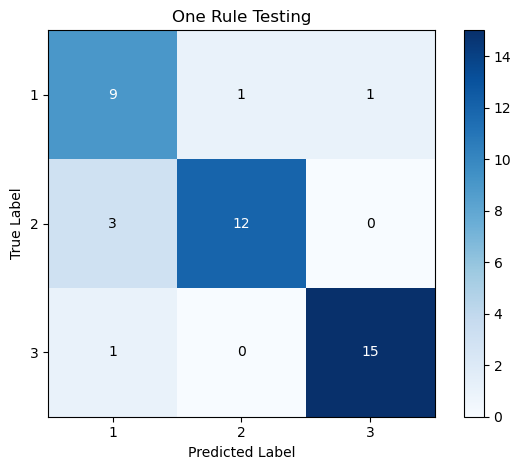

Please select an algorithm to run: 1 - 1-Rule, 2 - Naive Bayes, 3 - Decision Tree, 4 - k Nearest Neighbours


 2


Naive Bayes accuracy with 100 bins: training = 0.9819277108433735, testing = 0.8333333333333334


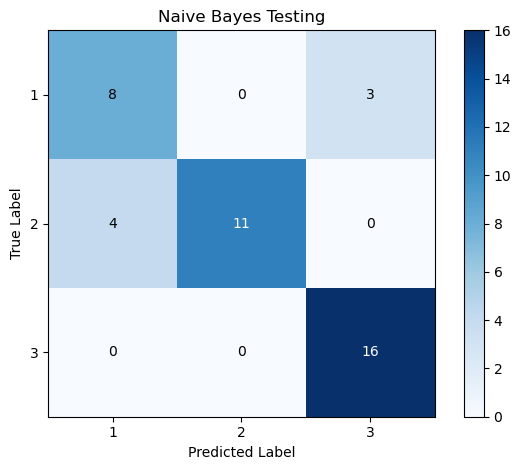

Please select an algorithm to run: 1 - 1-Rule, 2 - Naive Bayes, 3 - Decision Tree, 4 - k Nearest Neighbours


 3


Train Accuracy: 0.9939759036144579
Test Accuracy: 0.9047619047619048


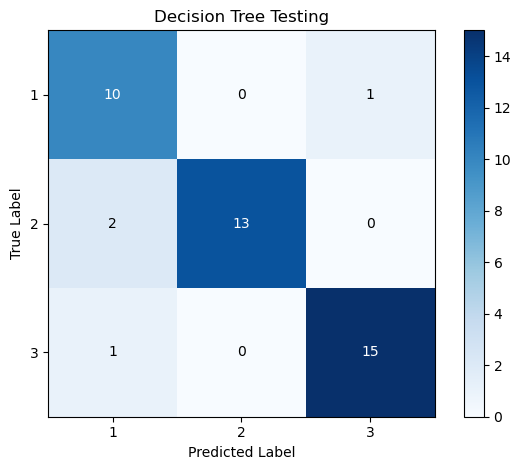

Please select an algorithm to run: 1 - 1-Rule, 2 - Naive Bayes, 3 - Decision Tree, 4 - k Nearest Neighbours


 4


Accuracy of 1 neighbours: 0.8809523809523809
Accuracy of 2 neighbours: 0.8809523809523809
Accuracy of 3 neighbours: 0.8809523809523809
Accuracy of 4 neighbours: 0.8809523809523809
Accuracy of 5 neighbours: 0.9285714285714286
Accuracy of 6 neighbours: 0.9047619047619048
Accuracy of 7 neighbours: 0.9523809523809523
Accuracy of 8 neighbours: 0.9285714285714286
Accuracy of 9 neighbours: 0.9523809523809523
Accuracy of 10 neighbours: 0.9285714285714286


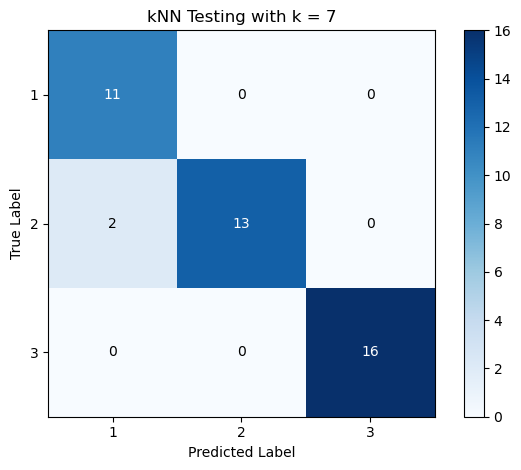

Please select an algorithm to run: 1 - 1-Rule, 2 - Naive Bayes, 3 - Decision Tree, 4 - k Nearest Neighbours


 0


In [15]:
while (1):
    print("Please select an algorithm to run: 1 - 1-Rule, 2 - Naive Bayes, 3 - Decision Tree, 4 - k Nearest Neighbours")
    option = int(input())

    if option == 1:
        train, test, confusion = oneRule(trainX, trainY, testX, testY, 40)
        print("1-rule accuracy with {} bins: training = {}, testing = {}".format(bins, train, test))
        plotConfusionMatrix(confusion, "One Rule Testing")
    elif option == 2:
        train, test, confusion = naiveBayes(trainX, testX, trainY, testY, 75)
        print("Naive Bayes accuracy with {} bins: training = {}, testing = {}".format(bins, train, test))
        plotConfusionMatrix(confusion, "Naive Bayes Testing")
    elif option == 3:
        tree = DecisionTree(max_depth=5)
        tree.trainTree(trainX, trainY)
        confusion = tree.evaluate(trainX, trainY, testX, testY)
        plotConfusionMatrix(confusion, "Decision Tree Testing")
    elif option == 4:
        k, confusion = kNearestNeighbours(trainX, testX, trainY, testY)
        plotConfusionMatrix(confusion, "kNN Testing with k = {}".format(k))
    elif option == 0:
        break
    else:
        print("Incorrect option")


## Висновки

Отже, у даній роботі були розглянуті та імплементовані чотири алгоритми класифікації на прикладі датасету "Seeds". Тестування показало, що усі ці алгоритми добре впоралися із задачею класифікації, хоча деякі з них - наприклад, 1-Rule - виявили вразливість до розподілу даних, що вивчаються, а інші - як, наприклад, kNN - за високої точності виявили потребу в докладному та тонкому підборі гіперпараметрів для отримання оптимальних результатів. За своїм значенням найкращої точності на тестовому наборі даних розглянуті класифікатори можуть бути впорядковані так:

|Classifier|Training accuracy|Test accuracy|
|:---:|:---:|:---:|
|kNN|---|95.24%|
|Decision Tree|99.40%|90.48%|
|Naive Bayes|98.19%|83.33%|
|1-Rule|90.96%|85.71%|